In [1]:
from umap import UMAP
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from scipy.spatial.transform import Rotation as R

# Change working directory
import os
os.chdir(os.getcwd() + "/../")

import config
import hyp_config
from visualisation.plotting import plot_embedding

In [2]:
def rotate_umap(u, x, y, z, factor=1):
    """ Rotating the embedding around x, y and z axis. """
    rx = R.from_euler('x', x, degrees=True)
    ry = R.from_euler('y', y, degrees=True)
    rz = R.from_euler('z', z, degrees=True)
    factor = float(factor)
    u_r = rx.apply(ry.apply(rz.apply(factor*u)))
    return u_r

# UMAP hyperparameter investigation
The parameters were selected such that the dimensionality-reduced space exhibits a distinct topology. Main parameters to tune:
- **min_dist**: Increasing the minimum distance between points caused the data points to spread further apart diluting finer topologies. 
- **n_neighbors**: A lower number of neighbours led to a more curled up structure while a higher number unfolded it. Increasing the parameter to more than 20 did not further change the embedding significantly.
- **n_components**: The number of dimensions of the embedding.

In [3]:
# Load data
df = pd.read_csv(f"{config.output_dir}wide_table_knn.csv")

# Scale data
scaler = MinMaxScaler().fit(df[config.parameters])
X = pd.DataFrame(scaler.transform(df[config.parameters]), columns=config.parameters)

In [3]:
# Compute UMAP embeddings with differing hyperparameters
param_combos = [{"min_dist": 0.0, "n_components": 3, "n_neighbors":20, "metric": "euclidean"}, 
                {"min_dist": 0.1, "n_components": 3, "n_neighbors":20, "metric": "euclidean"}, 
                {"min_dist": 0.5, "n_components": 3, "n_neighbors":20, "metric": "euclidean"},
                {"min_dist": 0.0, "n_components": 3, "n_neighbors":5, "metric": "euclidean"},
                {"min_dist": 0.0, "n_components": 3, "n_neighbors":100, "metric": "euclidean"}, 
                {"min_dist": 0.0, "n_components": 3, "n_neighbors":40, "metric": "mahalanobis"}, 
                {"min_dist": 0.0, "n_components": 3, "n_neighbors":20, "metric": "braycurtis"}, 
                {"min_dist": 0.0, "n_components": 3, "n_neighbors":20, "metric": "cosine"} 
               ]

min_dist =  0.0
n_components = 3
n_neighbors = 20
metric = euclidean


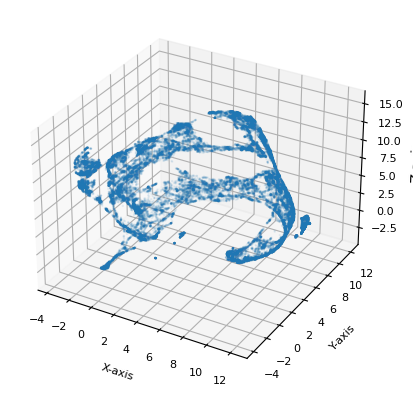

min_dist =  0.1
n_components = 3
n_neighbors = 20
metric = euclidean


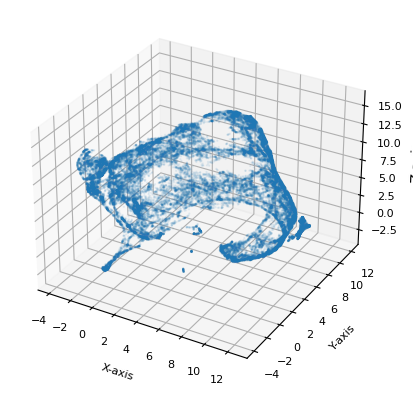

min_dist =  0.5
n_components = 3
n_neighbors = 20
metric = euclidean


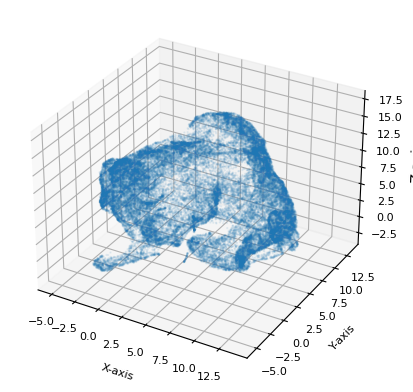

min_dist =  0.0
n_components = 3
n_neighbors = 5
metric = euclidean


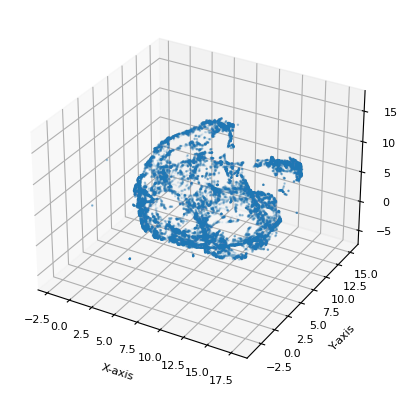

min_dist =  0.0
n_components = 3
n_neighbors = 100
metric = euclidean


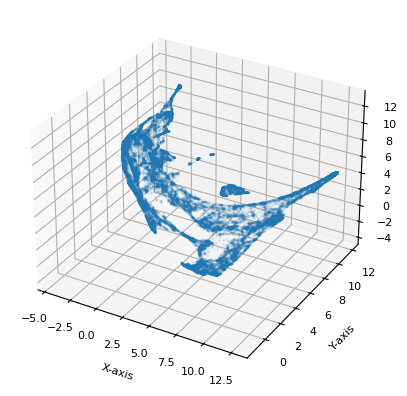

min_dist =  0.0
n_components = 3
n_neighbors = 40
metric = mahalanobis


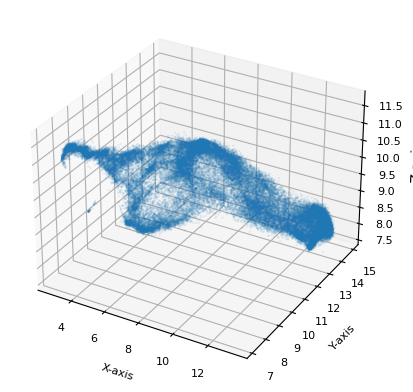

min_dist =  0.0
n_components = 3
n_neighbors = 20
metric = braycurtis


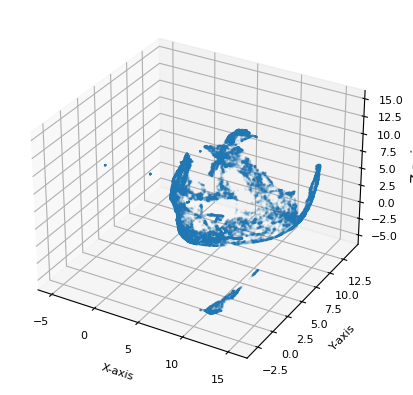

min_dist =  0.0
n_components = 3
n_neighbors = 20
metric = cosine


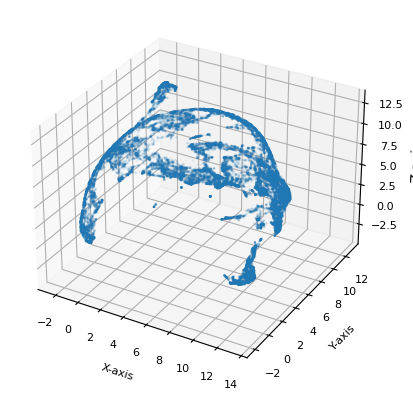

In [4]:
# Iterate over combinations (and repeat combination until plot has correct rotation for final plot)
embeddings = []
for umap_kwargs in param_combos: 
    print(f"min_dist =  {umap_kwargs['min_dist']}\nn_components = {umap_kwargs['n_components']}\nn_neighbors = {umap_kwargs['n_neighbors']}\nmetric = {umap_kwargs['metric']}")

    # Compute and plot embedding
    embedding = UMAP(**umap_kwargs).fit_transform(X)
    plot_embedding(embedding, figsize=(4, 4), dpi=300, save_as=None)
    
    # Append to results
    if answer == "y": 
        embeddings.append({"embedding": [embedding], 
                           "min_dist": umap_kwargs["min_dist"], 
                           "n_neighbors": umap_kwargs["n_neighbors"], 
                           "metric": umap_kwargs["metric"], 
                           "n_components": umap_kwargs["n_components"]})

In [ ]:
# Manually rotate if necessary/desired
# i = 0
# t = embeddings[i]["embedding"][0]
# n = rotate_umap(u, x, y, z, factor=1)
# embeddings[i]["embedding"] = [n]

In [146]:
# Save embeddings (for following plot)
for info in embeddings:
    e = info["embedding"]
    n_neighbors = info["n_neighbors"]
    min_dist = info["min_dist"]
    metric = info["metric"]
    n_components = info["n_components"]
    np.save(f"{config.output_dir_clustering}embedding_n_neighbors{n_neighbors}_min_dist{min_dist}_metric{metric}_n_components{n_components}.npy", e)

# Plotting wiht final hyperparameters

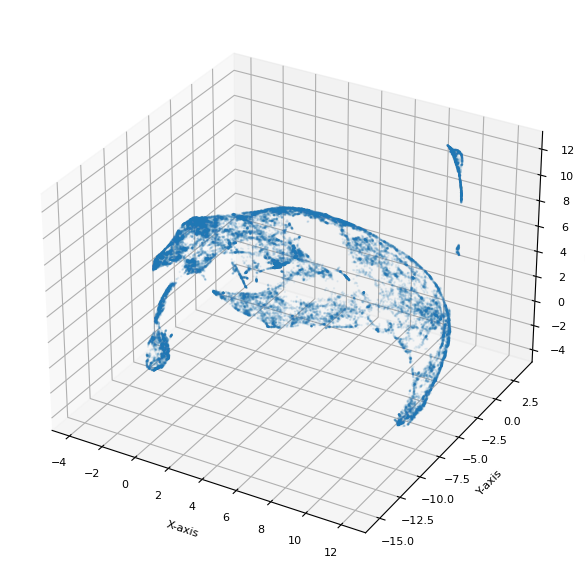

In [19]:
# Store a final UMAP plot
embedding = UMAP(**hyp_config.umap_hyps).fit_transform(X)
plot_embedding(embedding, save_as=f"{config.output_dir_plots_high_res}umap_space.png", dpi=1000, figsize=(6, 6))

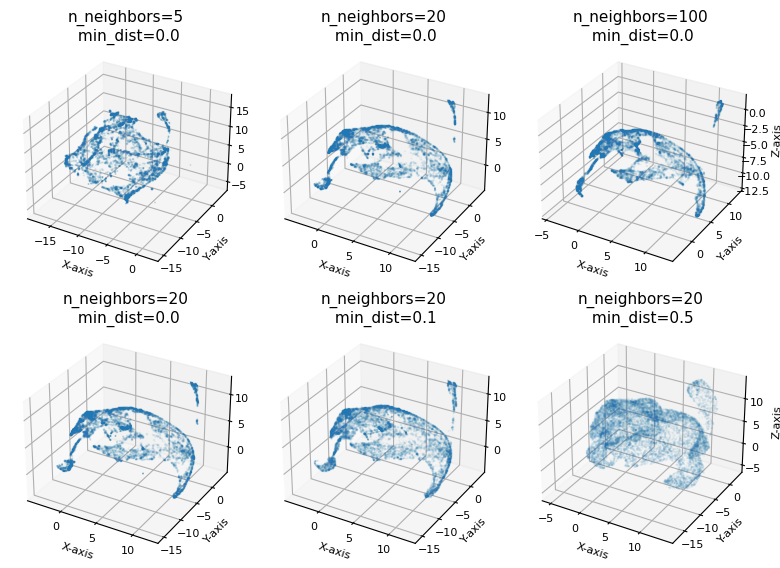

In [147]:
# Final plot
pad = 0
alpha = 0.08
size = 0.03
marker = ","
tick_label_size = 8
tick_padding = -3
label_size = 8
label_padding = -6
title_size = 11

fig, axs = plt.subplots(2, 3, subplot_kw={"projection": "3d"}, figsize=(8.27-pad, (8.27-pad)*0.7))  # A4 size in inches: 8.27 x 11.69

# Plot first row (varying n_neighbors)
for i, n_neighbors in enumerate([5, 20, 100]):
    min_dist = "0.0"
    i = int(i)

    # Load embedding
    e = np.load(f'{config.output_dir_clustering}embedding_n_neighbors{n_neighbors}_min_dist{min_dist}_metriceuclidean_n_components3.npy')[0]

    axs[0, i].scatter(e[:, 0], e[:, 1], e[:, 2], alpha=alpha, s=size, marker=marker)
    axs[0, i].set_title(f"n_neighbors={n_neighbors}\n min_dist={min_dist}", fontsize=title_size, pad=0)
    axs[0, i].set_xlabel('X-axis', fontsize=label_size, labelpad=label_padding)
    axs[0, i].set_ylabel('Y-axis', fontsize=label_size, labelpad=label_padding)

    if i == 2:
        axs[0, i].set_zlabel('Z-axis', fontsize=label_size, labelpad=label_padding)

    # Set tick label sizes
    axs[0, i].tick_params(axis='x', labelsize=tick_label_size, pad=tick_padding)
    axs[0, i].tick_params(axis='y', labelsize=tick_label_size, pad=tick_padding)
    axs[0, i].tick_params(axis='z', labelsize=tick_label_size, pad=tick_padding)

# Plot second row (varying min_dist)
for i, min_dist in enumerate([0.0, 0.1, 0.5]):
    n_neighbors = 20
    i = int(i)

    # Load embedding
    e = np.load(f"{config.output_dir_clustering}embedding_n_neighbors{n_neighbors}_min_dist{min_dist}_metriceuclidean_n_components3.npy")[0]

    axs[1, i].scatter(e[:, 0], e[:, 1], e[:, 2], alpha=alpha, s=size, marker=marker)
    axs[1, i].set_title(f"n_neighbors={n_neighbors}\n min_dist={min_dist}", fontsize=title_size, pad=0)
    axs[1, i].set_xlabel('X-axis', fontsize=label_size, labelpad=label_padding)
    axs[1, i].set_ylabel('Y-axis', fontsize=label_size, labelpad=label_padding)

    if i == 2:
        axs[1, i].set_zlabel('Z-axis', fontsize=label_size, labelpad=label_padding)

    # Set tick label sizes
    axs[1, i].tick_params(axis='x', labelsize=tick_label_size, pad=tick_padding)
    axs[1, i].tick_params(axis='y', labelsize=tick_label_size, pad=tick_padding)
    axs[1, i].tick_params(axis='z', labelsize=tick_label_size, pad=tick_padding)

plt.subplots_adjust(hspace=1)
plt.tight_layout()
#plt.savefig(f"{config.output_dir_plots}umap_hyperparameters.png", dpi=300)
plt.savefig(f"{config.output_dir_plots_high_res}umap_hyperparameters.png", dpi=1000)
plt.show()